In [ ]:
import math
import numpy as np
import scipy.integrate as integrate
from scipy.special import gamma
import matplotlib.pyplot as plt

# define a beta function prior and likelihood
def prior(alpha, beta, theta):

    return gamma(alpha+beta)/gamma(alpha)/gamma(beta) * theta**(alpha-1) * (1-theta)**(beta-1)

def likelihood(n, h, theta):

    return math.comb(n, h) * theta**h * (1-theta)**(n-h)

In [257]:
# define the posterior with inputs for the (beta) prior and new data
def posterior(alpha, beta, n, h):

    # define the integrand for easier computations
    def product(theta):
        return prior(alpha, beta, theta) * likelihood(n, h, theta)
    
    # initialize posterior with resolution of 1000
    post_arr = []
    theta_arr = np.linspace(0, 1, 1000)

    # update posterior array with (prior * likelihood)
    for theta in theta_arr:
        post_arr.append(product(theta))

    # turn to numpy array to normalize
    post_arr = np.array(post_arr)
    
    # find normalizaiton factor by integrating
    norm,_ = integrate.quad(product, 0, 1)

    plt.plot(theta_arr, post_arr / norm, label=f'n = {n}, h = {h}')
    plt.xlabel(r'$\theta$')
    plt.ylabel('Probability Density')
    plt.legend()

    return theta_arr, post_arr/norm


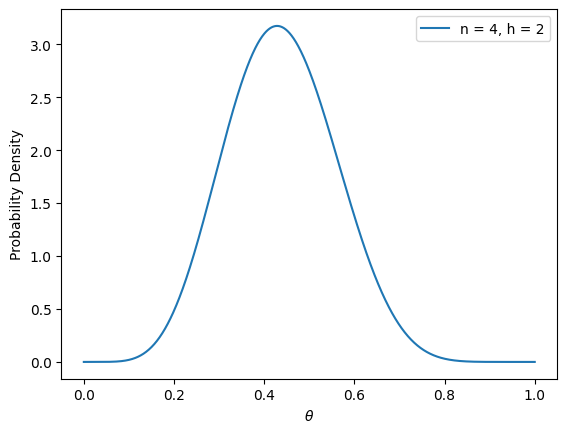

In [259]:
# find posterior for priors [5,7] and new data of 2 heads in 4 flips
coin_arr, coin_post = posterior(5,7,4,2)

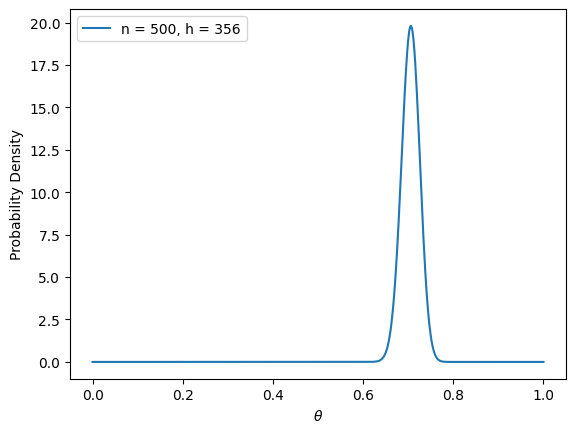

In [262]:
# load data, since successes are stored as 1 we can sum to find total

data = np.loadtxt('HW06_data.txt')
n = len(data)
h = np.sum(data).astype(int)

_, _ = posterior(5,7,n,h)

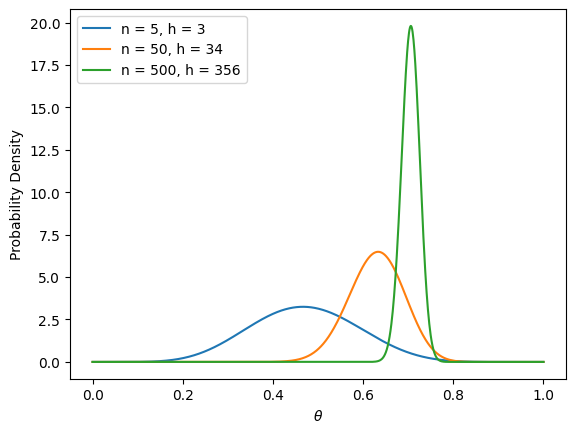

In [263]:
# plotting several N values
n_arr = [5, 50, 500]

for n in n_arr:
    h = np.sum(data[:n]).astype(int)
    posterior(5,7,n,h)

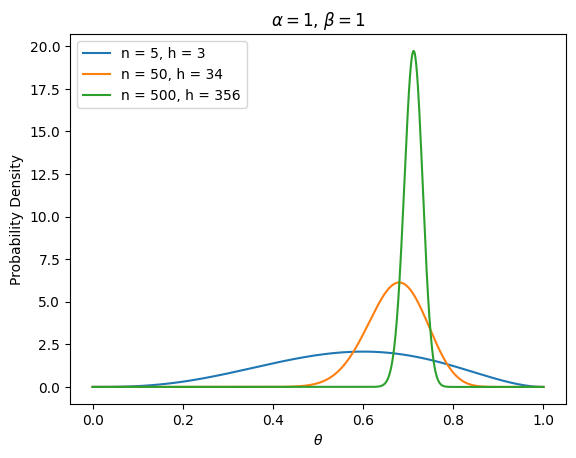

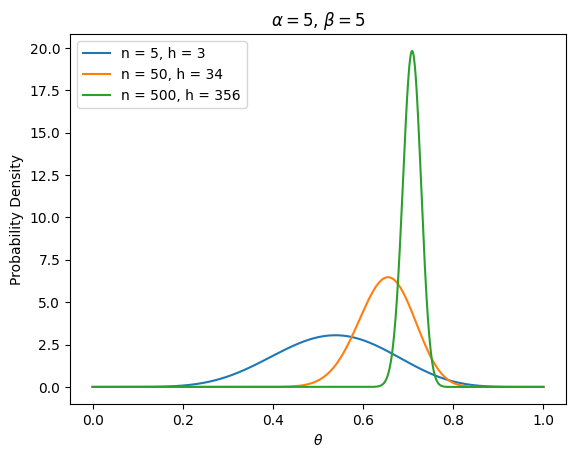

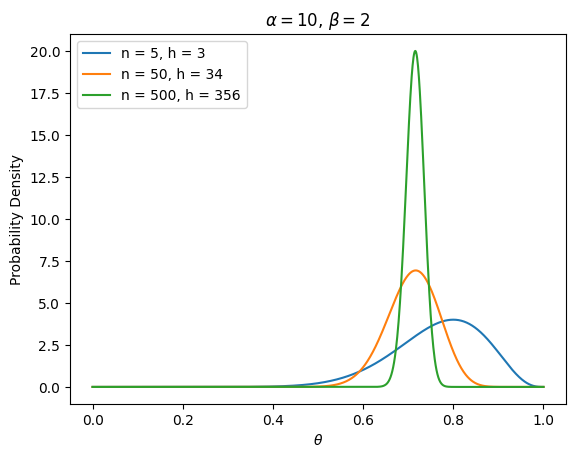

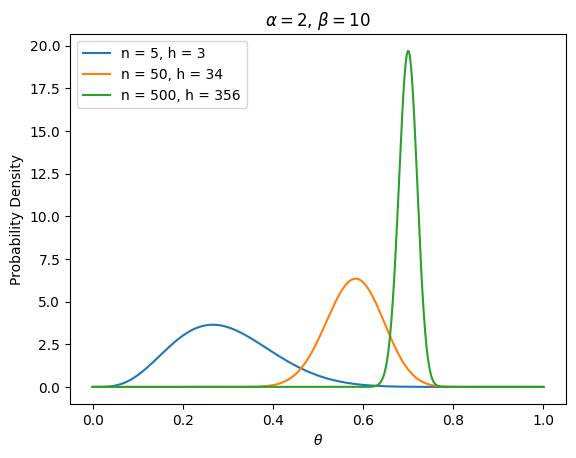

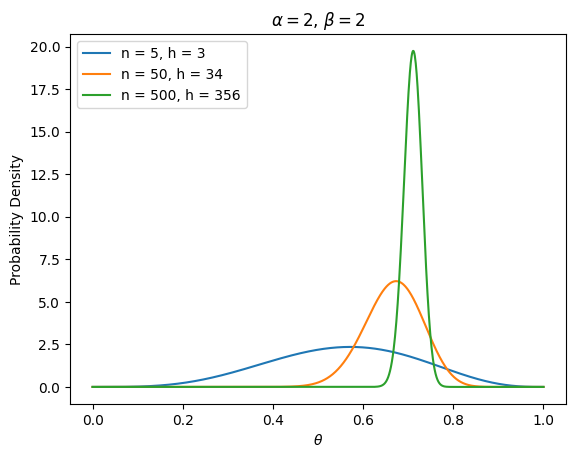

In [266]:
# repeat last part, but now with unique priors as given in slides
prior_arr = [[1,1],[5,5],[10,2],[2,10],[2,2]]

for priors in prior_arr:

    alpha = priors[0]
    beta = priors[1]

    for n in n_arr:
        h = np.sum(data[:n]).astype(int)
        _,_ = posterior(alpha,beta,n,h)

    plt.title(rf'$\alpha = {alpha}$, $\beta = {beta}$')
    plt.show()

In [267]:
# randomly generate N points in a square
N=100

data_x = np.random.rand(N)
data_y = np.random.rand(N)

index_in = []
index_out = []

# store the indices of points inside vs outside the unit (quarter) circle
for i in range(len(data_x)):
    r_i = np.sqrt(data_x[i]**2+data_y[i]**2)

    if r_i < 1:
        index_in.append(i)
    else:
        index_out.append(i)

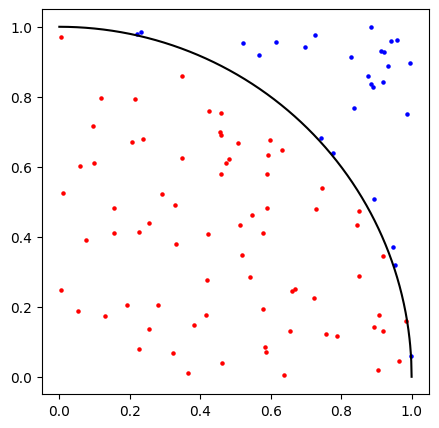

In [268]:
# plot with colors from stored indices
plt.figure(figsize=(5,5))

plt.scatter(data_x[index_in], data_y[index_in], color='red', s=5)
plt.scatter(data_x[index_out], data_y[index_out], color='blue', s=5)

x = np.linspace(0,1,1000)
plt.plot(x, np.sqrt(1-x**2), color='black')

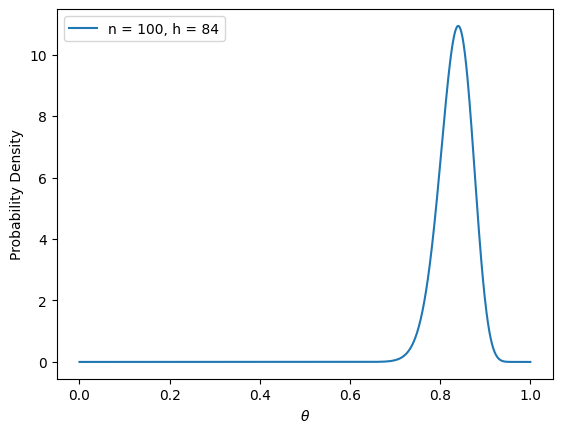

In [207]:
pi_est = posterior(1,1,N,len(index_in))

The estimate for pi is 2.8990588235294115 with a 95% confidence interval of [2.5425425425425425, 3.2272272272272273]


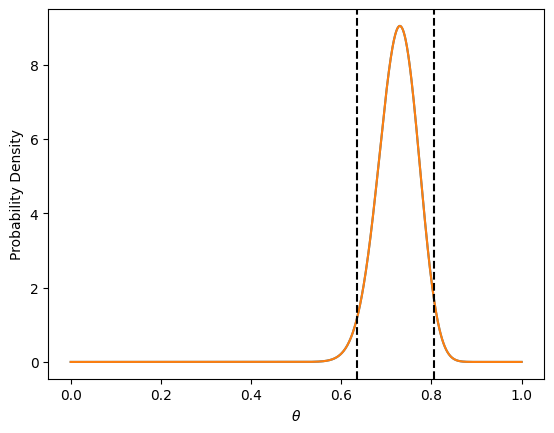

In [269]:
# generate PDF of probability that a point is inside the circle with flat priors
theta_arr, pi_post = posterior(1,1,N,len(index_in))

# use this probability to estimate pi using area ratios
pi_est = np.mean(theta_arr * pi_post)*4

# PDF resolution for CDF computation
dtheta = theta_arr[1]-theta_arr[0]

# compute CDF to find percentiles
cdf = np.cumsum(pi_post)*dtheta
pi_low = theta_arr[np.searchsorted(cdf, 0.025)] * 4
pi_high = theta_arr[np.searchsorted(cdf, 0.975)] * 4

# plot with 95 percentile (dotted) lines
plt.plot(theta_arr, pi_post)
plt.xlabel(r'$\theta$')
plt.ylabel('Probability Density')
plt.gca().get_legend().remove()

plt.axvline(pi_low / 4, linestyle='--', color='black')
plt.axvline(pi_high / 4, linestyle='--', color='black')

print(f'The estimate for pi is {pi_est} with a 95% confidence interval of [{pi_low}, {pi_high}]')

In [248]:
mean

np.float64(0.0)

In [192]:
pi = pi_est[0][np.where(pi_est[1] == np.max(pi_est[1]))] * 4
pi

array([3.14314314])

In [ ]:
prior_arr = [[1,1],[5,5],[10,2],[2,10],[2,2]]
for priors in prior_arr:

    alpha = priors[0]
    beta = priors[1]

    for n in n_arr:
        h = np.sum(data[:n]).astype(int)
        posterior(alpha,beta,n,h)

    plt.title(rf'$\alpha = {alpha}$, $\beta = {beta}$')
    plt.show()